# This notebook replicates Lai's vote outcome modeling using PTs

In [ ]:
from pathlib import Path
import sys
import importlib
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as 

def find_repo_root(start: Optional[Path] = None, repo_name: str = "masters_thesis_sdg") -> Path:
    if start is None:
        start = Path.cwd().resolve()

    current = start
    while True:
        if current.name == repo_name:
            return current

        if current.parent == current:
            raise FileNotFoundError(
                f"Could not find repo root '{repo_name}' starting from {start}"
            )

        current = current.parent


PROJECT_ROOT = find_repo_root()
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "lai2023"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)
print("DATA_DIR:", DATA_DIR)

In [31]:
from utils_analysis.lai2023_loading import (
    load_annotation_splits,
    load_outcome_index,
    count_games_by_split,
)

from utils_analysis.row_builders import (
    build_human_rows_by_split,
    build_human_pairwise_rows,
    build_human_temporal_pairwise_rows,
    build_human_candidate_only_rows,
    build_human_temporal_candidate_only_rows,
)

from utils_analysis.strategy_features import (
    rows_to_xy,
    get_feature_names,
)

from utils_analysis.logreg_eval import (
    run_tuned_logreg_with_classweight_search,
    metrics_table,
    eval_group_ranking,
)

## 1. Load annotation splits and human voting outcomes

In [11]:
annot_splits = load_annotation_splits(DATA_DIR)
outcome_index = load_outcome_index(DATA_DIR)

print("Games by split:")
display(pd.DataFrame(count_games_by_split(annot_splits)).T)

print("Outcome sessions:")
print({dataset: len(sessions) for dataset, sessions in outcome_index.items()})

Games by split:


,train,val,test
yt,105,16,30
ego4d,28,4,8


Outcome sessions:
{'yt': 57, 'ego4d': 11}


### Player/group statistics

In [15]:
from collections import Counter

def extract_player_and_group_stats(annot_splits, outcome_index):
    all_players = set()
    group_counter = Counter()
    game_counter = 0

    for dataset, split_map in annot_splits.items():
        for split, games in split_map.items():
            for game in games:
                game_counter += 1
                outcome = get_outcome_record(game, dataset, outcome_index)
                players = outcome["playerNames"]
                all_players.update(players)
                group_counter[tuple(sorted(players))] += 1

    return all_players, group_counter, game_counter

all_players, group_counter, total_games = extract_player_and_group_stats(
    annot_splits,
    outcome_index,
)

print("Total games:", total_games)
print("Unique player names:", len(all_players))
print("Unique groups:", len(group_counter))

group_df = pd.DataFrame([
    {
        "group_size": len(group),
        "num_games": count,
        "players": ", ".join(group),
    }
    for group, count in group_counter.items()
]).sort_values(["num_games", "group_size"], ascending=[False, False])

group_df.head(20)

Total games: 191
Unique player names: 60
Unique groups: 36


,group_size,num_games,players
4,4,18,"Justin, Mike, Mitchell, Paul"
0,5,15,"James, Justin, Laura, Mitchell, Paul"
6,5,12,"Caitlynn, James, Justin, Mike, Mitchell"
31,4,12,"Daniel, Jessica, Kaelan, Kevin"
32,4,11,"Hunter, Jacob, Sean, Zack"
10,4,10,"Alana, Caitlynn, Mike, Mitchell"
15,4,10,"Alvin, James, Justin, Mitchell"
34,6,9,"Ashley, Chris, Elliot, James, Sian, Sukeshi"
7,5,9,"Eric, Justin, Mike, Mitchell, Paul"
2,5,8,"Caitlynn, Dan, Justin, Mike, Mitchell"


## 3. Build aggregate pairwise rows

In [17]:
# Strategies + voter start-role one-hot
rows_full = build_human_rows_by_split(
    annot_splits,
    outcome_index,
    row_builder=build_human_pairwise_rows,
    include_roles=True,
)

# Strategies only
rows_strategy = build_human_rows_by_split(
    annot_splits,
    outcome_index,
    row_builder=build_human_pairwise_rows,
    include_roles=False,
)

for name, split_rows in [
    ("strategies + roles", rows_full),
    ("strategies only", rows_strategy),
]:
    print("\n", name)
    for split, rows in split_rows.items():
        y = np.array([r["label"] for r in rows])
        print(split, "rows:", len(rows), "positive rate:", y.mean())


 strategies + roles
train rows: 2741 positive rate: 0.20977745348412988
val rows: 445 positive rate: 0.20449438202247192
test rows: 836 positive rate: 0.18181818181818182

 strategies only
train rows: 2741 positive rate: 0.20977745348412988
val rows: 445 positive rate: 0.20449438202247192
test rows: 836 positive rate: 0.18181818181818182


In [18]:
X_train, y_train = rows_to_xy(rows_full["train"])
X_val, y_val = rows_to_xy(rows_full["val"])
X_test, y_test = rows_to_xy(rows_full["test"])

X_train_nr, y_train_nr = rows_to_xy(rows_strategy["train"])
X_val_nr, y_val_nr = rows_to_xy(rows_strategy["val"])
X_test_nr, y_test_nr = rows_to_xy(rows_strategy["test"])

print("With roles:")
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

print("\nNo roles:")
print(X_train_nr.shape, y_train_nr.shape)
print(X_val_nr.shape, y_val_nr.shape)
print(X_test_nr.shape, y_test_nr.shape)

print("\nFeature dims with roles:", X_train.shape[1])
print("Feature dims no roles:", X_train_nr.shape[1])

With roles:
(2741, 26) (2741,)
(445, 26) (445,)
(836, 26) (836,)

No roles:
(2741, 14) (2741,)
(445, 14) (445,)
(836, 14) (836,)

Feature dims with roles: 26
Feature dims no roles: 14


## 4. Paper-faithful logistic regression

This keeps fixed hyperparameters from the paper:

- strategy-only: `class_weight={0:1.0, 1:4.2}`, `C=1.4`
- strategies + role: `class_weight={0:1.0, 1:4.8}`, `C=0.8`

The data/features come from the utils; this local function only preserves the exact fixed paper-style LR setting.

In [20]:
def select_split_arrays(include_roles):
    if include_roles:
        return X_train, y_train, X_val, y_val, X_test, y_test
    return X_train_nr, y_train_nr, X_val_nr, y_val_nr, X_test_nr, y_test_nr


def run_logreg_paper_exact(include_roles=True):
    """
    Mirrors the fixed logistic-regression setup from the original notebook.

    Uses hard predictions for F1/AUC, exactly as in the old cell.
    """
    X_tr, y_tr, X_va, y_va, X_te, y_te = select_split_arrays(include_roles)

    if include_roles:
        class_weight = {0: 1.0, 1: 4.8}
        C = 0.8
    else:
        class_weight = {0: 1.0, 1: 4.2}
        C = 1.4

    model = LogisticRegression(
        class_weight=class_weight,
        C=C,
        max_iter=2000,
        random_state=42,
    )
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    val_pred = model.predict(X_va)
    test_pred = model.predict(X_te)

    def hard_metrics(y_true, y_pred):
        return {
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "auc_hard": roc_auc_score(y_true, y_pred),
            "accuracy": accuracy_score(y_true, y_pred),
            "positive_rate": y_true.mean(),
            "predicted_positive_rate": y_pred.mean(),
        }

    feature_names = get_feature_names(
        "pairwise_aggregate",
        include_roles=include_roles,
    )

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": model.coef_[0],
    }).sort_values("coef", ascending=False)

    return {
        "include_roles": include_roles,
        "C": C,
        "class_weight": class_weight,
        "model": model,
        "train_metrics": hard_metrics(y_tr, train_pred),
        "val_metrics": hard_metrics(y_va, val_pred),
        "test_metrics": hard_metrics(y_te, test_pred),
        "coef_df": coef_df,
        "train_pred": train_pred,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }


paper_strat = run_logreg_paper_exact(include_roles=False)
paper_full = run_logreg_paper_exact(include_roles=True)

comparison_paper = pd.DataFrame([
    {
        "model": "paper exact - strategies only",
        "roles": False,
        "C": paper_strat["C"],
        "class_weight": str(paper_strat["class_weight"]),
        "test_f1": paper_strat["test_metrics"]["f1"],
        "test_auc_hard": paper_strat["test_metrics"]["auc_hard"],
        "test_accuracy": paper_strat["test_metrics"]["accuracy"],
    },
    {
        "model": "paper exact - strategies + role",
        "roles": True,
        "C": paper_full["C"],
        "class_weight": str(paper_full["class_weight"]),
        "test_f1": paper_full["test_metrics"]["f1"],
        "test_auc_hard": paper_full["test_metrics"]["auc_hard"],
        "test_accuracy": paper_full["test_metrics"]["accuracy"],
    },
])

comparison_paper

,model,roles,C,class_weight,test_f1,test_auc_hard,test_accuracy
0,paper exact - strategies only,False,1.4,"{0: 1.0, 1: 4.2}",0.323288,0.551901,0.409091
1,paper exact - strategies + role,True,0.8,"{0: 1.0, 1: 4.8}",0.323810,0.543860,0.320574


## 5. Interpret aggregate coefficients

In [21]:
coef_df_no_roles = paper_strat["coef_df"]
coef_df_no_roles

,feature,coef
11,candidate_Call for Action,1.944057
8,candidate_Identity Declaration,1.274154
12,candidate_Defense,0.890622
6,voter_Evidence,0.871672
3,voter_Interrogation,0.850130
2,voter_Accusation,0.756514
0,voter_No Strategy,0.552654
10,candidate_Interrogation,0.517724
7,candidate_No Strategy,0.431728
4,voter_Call for Action,0.186772


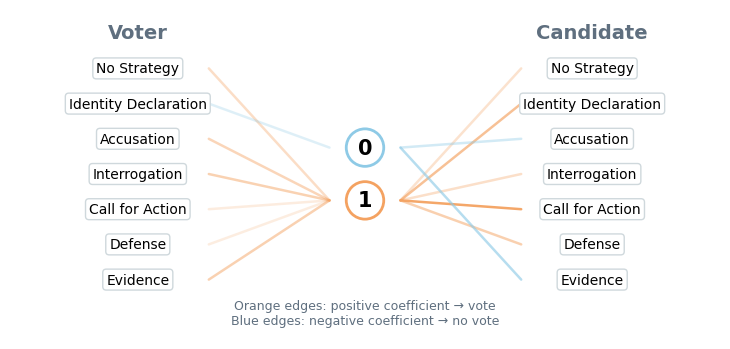

In [22]:
def plot_figure6_paper_like(
    coef_df_no_roles,
    color_zero="#8ecae6",
    color_one="#f4a261",
    min_alpha=0.12,
    max_alpha=0.95,
    linewidth=1.8,
    gamma=1.0,
):
    """
    Kept from the original notebook because this is custom visualization code,
    not core data/model logic.
    """
    strategies = STRATEGIES

    coef_map = dict(zip(coef_df_no_roles["feature"], coef_df_no_roles["coef"]))

    voter_feats = [f"voter_{s}" for s in strategies]
    cand_feats = [f"candidate_{s}" for s in strategies]

    voter_coefs = [coef_map.get(f, 0.0) for f in voter_feats]
    cand_coefs = [coef_map.get(f, 0.0) for f in cand_feats]

    y_positions = np.linspace(0.82, 0.18, len(strategies))
    x_voter = 0.18
    x_candidate = 0.82
    x_center = 0.50
    y_zero = 0.58
    y_one = 0.42

    fig, ax = plt.subplots(figsize=(7.4, 3.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    ax.text(
        x_voter,
        0.93,
        "Voter",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="#5f6f7f",
    )
    ax.text(
        x_candidate,
        0.93,
        "Candidate",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="#5f6f7f",
    )

    ax.text(
        x_center,
        y_zero,
        "0",
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        bbox=dict(boxstyle="circle,pad=0.42", fc="white", ec=color_zero, lw=2),
    )
    ax.text(
        x_center,
        y_one,
        "1",
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        bbox=dict(boxstyle="circle,pad=0.42", fc="white", ec=color_one, lw=2),
    )

    all_abs = np.abs(voter_coefs + cand_coefs)
    max_abs = max(all_abs) if len(all_abs) and max(all_abs) > 0 else 1.0

    def draw_edge(x0, y0, x1, y1, coef):
        if coef == 0:
            return

        target_y = y_one if coef > 0 else y_zero
        color = color_one if coef > 0 else color_zero

        strength = (abs(coef) / max_abs) ** gamma
        alpha = min_alpha + (max_alpha - min_alpha) * strength

        ax.plot(
            [x0, x1],
            [y0, target_y],
            color=color,
            alpha=alpha,
            linewidth=linewidth,
            solid_capstyle="round",
        )

    for y, s, coef in zip(y_positions, strategies, voter_coefs):
        ax.text(
            x_voter,
            y,
            s,
            ha="center",
            va="center",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#cfd8dc", lw=1),
        )
        draw_edge(x_voter + 0.10, y, x_center - 0.05, y_one if coef > 0 else y_zero, coef)

    for y, s, coef in zip(y_positions, strategies, cand_coefs):
        ax.text(
            x_candidate,
            y,
            s,
            ha="center",
            va="center",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#cfd8dc", lw=1),
        )
        draw_edge(x_candidate - 0.10, y, x_center + 0.05, y_one if coef > 0 else y_zero, coef)

    ax.text(
        x_center,
        0.08,
        "Orange edges: positive coefficient → vote\nBlue edges: negative coefficient → no vote",
        ha="center",
        va="center",
        fontsize=9,
        color="#5f6f7f",
    )

    plt.tight_layout()
    plt.show()


plot_figure6_paper_like(coef_df_no_roles)

## 6. Tuned temporal pairwise logistic regression


In [23]:
rows_temporal = build_human_rows_by_split(
    annot_splits,
    outcome_index,
    row_builder=build_human_temporal_pairwise_rows,
)

X_train_temp, y_train_temp = rows_to_xy(rows_temporal["train"])
X_val_temp, y_val_temp = rows_to_xy(rows_temporal["val"])
X_test_temp, y_test_temp = rows_to_xy(rows_temporal["test"])

feature_names_temp = get_feature_names("pairwise_temporal")

print("Temporal model shapes:", X_train_temp.shape, X_val_temp.shape, X_test_temp.shape)
print("Num features:", len(feature_names_temp))

Temporal model shapes: (2741, 28) (445, 28) (836, 28)
Num features: 28


In [24]:
res_temp = run_tuned_logreg_with_classweight_search(
    X_train_temp, y_train_temp,
    X_val_temp, y_val_temp,
    X_test_temp, y_test_temp,
    feature_names_temp,
    c_grid=(0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.4, 2.0, 3.0),
    class_weight_grid=(
        None,
        "balanced",
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        {0: 1, 1: 5},
    ),
    solver="liblinear",
    optimize_for="f1",
)

print("Best C:", res_temp["best_C"])
print("Best class_weight:", res_temp["best_class_weight"])
print("Best threshold:", res_temp["best_threshold"])

display(metrics_table(res_temp))
display(res_temp["coef_df"].sort_values("coef", ascending=False))

Best C: 0.1
Best class_weight: {0: 1, 1: 4}
Best threshold: 0.49


,split,threshold,f1,auc_prob,accuracy,positive_rate,predicted_positive_rate
0,train,0.49,0.360953,0.571648,0.383802,0.209777,0.754469
1,val,0.49,0.352941,0.544080,0.332584,0.204494,0.826966
2,test,0.49,0.333333,0.580236,0.401914,0.181818,0.715311


,feature,coef
25,candidate_late_Call for Action,0.846045
17,candidate_early_Interrogation,0.374611
14,candidate_early_No Strategy,0.335490
19,candidate_early_Defense,0.293314
10,voter_late_Interrogation,0.256939
15,candidate_early_Identity Declaration,0.218808
26,candidate_late_Defense,0.211122
13,voter_late_Evidence,0.197467
2,voter_early_Accusation,0.191422
3,voter_early_Interrogation,0.161898


## 7. Tuned aggregate candidate-only logistic regression



In [25]:
rows_candidate = build_human_rows_by_split(
    annot_splits,
    outcome_index,
    row_builder=build_human_candidate_only_rows,
)

X_train_cand, y_train_cand = rows_to_xy(rows_candidate["train"])
X_val_cand, y_val_cand = rows_to_xy(rows_candidate["val"])
X_test_cand, y_test_cand = rows_to_xy(rows_candidate["test"])

feature_names_cand = get_feature_names("candidate_aggregate")

print("Candidate-only aggregate shapes:", X_train_cand.shape, X_val_cand.shape, X_test_cand.shape)
print("Num features:", len(feature_names_cand))

Candidate-only aggregate shapes: (2741, 7) (445, 7) (836, 7)
Num features: 7


In [26]:
res_cand = run_tuned_logreg_with_classweight_search(
    X_train_cand, y_train_cand,
    X_val_cand, y_val_cand,
    X_test_cand, y_test_cand,
    feature_names_cand,
    c_grid=(0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.4, 2.0, 3.0),
    class_weight_grid=(
        None,
        "balanced",
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        {0: 1, 1: 5},
    ),
    solver="liblinear",
    optimize_for="f1",
)

display(metrics_table(res_cand))
display(res_cand["coef_df"].sort_values("coef", ascending=False))

,split,threshold,f1,auc_prob,accuracy,positive_rate,predicted_positive_rate
0,train,0.27,0.344912,0.557140,0.415177,0.209777,0.682962
1,val,0.27,0.355450,0.546812,0.388764,0.204494,0.743820
2,test,0.27,0.318508,0.538969,0.431818,0.181818,0.651914


,feature,coef
4,candidate_Call for Action,1.756944
1,candidate_Identity Declaration,1.122822
5,candidate_Defense,0.803466
3,candidate_Interrogation,0.668850
0,candidate_No Strategy,0.525772
2,candidate_Accusation,-0.491964
6,candidate_Evidence,-0.989075


## 8. Tuned temporal candidate-only logistic regression


In [27]:
rows_temp_cand = build_human_rows_by_split(
    annot_splits,
    outcome_index,
    row_builder=build_human_temporal_candidate_only_rows,
)

X_train_temp_cand, y_train_temp_cand = rows_to_xy(rows_temp_cand["train"])
X_val_temp_cand, y_val_temp_cand = rows_to_xy(rows_temp_cand["val"])
X_test_temp_cand, y_test_temp_cand = rows_to_xy(rows_temp_cand["test"])

feature_names_temp_cand = get_feature_names("candidate_temporal")

print("Candidate-only temporal model shapes:",
      X_train_temp_cand.shape, X_val_temp_cand.shape, X_test_temp_cand.shape)
print("Num features:", len(feature_names_temp_cand))

Candidate-only temporal model shapes: (2741, 14) (445, 14) (836, 14)
Num features: 14


In [28]:
res_temp_cand = run_tuned_logreg_with_classweight_search(
    X_train_temp_cand, y_train_temp_cand,
    X_val_temp_cand, y_val_temp_cand,
    X_test_temp_cand, y_test_temp_cand,
    feature_names_temp_cand,
    c_grid=(0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.4, 2.0, 3.0),
    class_weight_grid=(
        None,
        "balanced",
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        {0: 1, 1: 5},
    ),
    solver="liblinear",
    optimize_for="f1",
)

display(metrics_table(res_temp_cand))
display(res_temp_cand["coef_df"].sort_values("coef", ascending=False))

,split,threshold,f1,auc_prob,accuracy,positive_rate,predicted_positive_rate
0,train,0.55,0.352185,0.569526,0.448377,0.209777,0.641737
1,val,0.55,0.373464,0.556156,0.426966,0.204494,0.710112
2,test,0.55,0.340299,0.571277,0.471292,0.181818,0.619617


,feature,coef
11,candidate_late_Call for Action,1.644647
3,candidate_early_Interrogation,0.951445
5,candidate_early_Defense,0.902276
0,candidate_early_No Strategy,0.765162
1,candidate_early_Identity Declaration,0.760442
8,candidate_late_Identity Declaration,0.495747
12,candidate_late_Defense,0.451424
2,candidate_early_Accusation,0.199737
7,candidate_late_No Strategy,0.068264
10,candidate_late_Interrogation,0.031624


## 9. Compare tuned models

In [ ]:
comparison_models = pd.DataFrame([
    {
        "model": "Temporal full",
        "features": X_test_temp.shape[1],
        "best_C": res_temp["best_C"],
        "best_class_weight": str(res_temp["best_class_weight"]),
        "threshold": res_temp["test_metrics"]["threshold"],
        "test_f1": res_temp["test_metrics"]["f1"],
        "test_auc": res_temp["test_metrics"]["auc_prob"],
        "test_accuracy": res_temp["test_metrics"]["accuracy"],
    },
    {
        "model": "Candidate only",
        "features": X_test_cand.shape[1],
        "best_C": res_cand["best_C"],
        "best_class_weight": str(res_cand["best_class_weight"]),
        "threshold": res_cand["test_metrics"]["threshold"],
        "test_f1": res_cand["test_metrics"]["f1"],
        "test_auc": res_cand["test_metrics"]["auc_prob"],
        "test_accuracy": res_cand["test_metrics"]["accuracy"],
    },
    {
        "model": "Temporal candidate only",
        "features": X_test_temp_cand.shape[1],
        "best_C": res_temp_cand["best_C"],
        "best_class_weight": str(res_temp_cand["best_class_weight"]),
        "threshold": res_temp_cand["test_metrics"]["threshold"],
        "test_f1": res_temp_cand["test_metrics"]["f1"],
        "test_auc": res_temp_cand["test_metrics"]["auc_prob"],
        "test_accuracy": res_temp_cand["test_metrics"]["accuracy"],
    },
])

comparison_models

## 10. Ranking evaluation

In [ ]:
def ranking_eval_for_result(name, split_rows, result):
    rank_rows = []

    for split in ["train", "val", "test"]:
        metrics, pred_df, scored_df = eval_group_ranking(
            split_rows[split],
            result[f"{split}_prob"],
            group_cols=("dataset", "session_key", "game_id", "voter"),
        )

        rank_rows.append({"model": name, "split": split, **metrics})

    return pd.DataFrame(rank_rows)


ranking_comparison = pd.concat(
    [
        ranking_eval_for_result("temporal_full", rows_temporal, res_temp),
        ranking_eval_for_result("candidate_only", rows_candidate, res_cand),
        ranking_eval_for_result("temporal_candidate_only", rows_temp_cand, res_temp_cand),
    ],
    ignore_index=True,
)

ranking_comparison

## 11. Save outputs

In [ ]:
OUT_DIR = PROJECT_ROOT / "results" / "analysis" / "human_vote_logreg_utils"
OUT_DIR.mkdir(parents=True, exist_ok=True)

comparison_paper.to_csv(OUT_DIR / "paper_exact_comparison.csv", index=False)
comparison_models.to_csv(OUT_DIR / "tuned_model_comparison.csv", index=False)
ranking_comparison.to_csv(OUT_DIR / "ranking_comparison.csv", index=False)

paper_strat["coef_df"].to_csv(OUT_DIR / "paper_strategy_only_coefficients.csv", index=False)
paper_full["coef_df"].to_csv(OUT_DIR / "paper_full_coefficients.csv", index=False)
res_temp["coef_df"].to_csv(OUT_DIR / "temporal_full_coefficients.csv", index=False)
res_cand["coef_df"].to_csv(OUT_DIR / "candidate_only_coefficients.csv", index=False)
res_temp_cand["coef_df"].to_csv(OUT_DIR / "temporal_candidate_only_coefficients.csv", index=False)

res_temp["search_df"].to_csv(OUT_DIR / "temporal_full_search.csv", index=False)
res_cand["search_df"].to_csv(OUT_DIR / "candidate_only_search.csv", index=False)
res_temp_cand["search_df"].to_csv(OUT_DIR / "temporal_candidate_only_search.csv", index=False)

print("Saved outputs to:", OUT_DIR)